In [11]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

### Carga

In [2]:
#features que descarto
# features_to_drop = ['WFO', 'SOURCE']
features_to_drop = ['WFO', 'SOURCE','CZ_TYPE',
                    'TIME_OF_DAY','MAGNITUDE_TYPE','YEAR',
                    'DAY_OF_WEEK','DAY_OF_YEAR','END_LAT',
                    'END_LON','BEGIN_LAT','BEGIN_LON',
                    'HAS_TRACK_DISTANCE','HAS_TORNADO_DATA','HAS_MAGNITUDE',
                    'MAGNITUDE','FLOOD_CAUSE']

In [3]:
# ---------------------------------------------------------
# 1. Load the Datasets
# ---------------------------------------------------------
print("Loading datasets...")

DATA_PATH = '../tp/processed_datasets/'
X_TRAIN_PATH = DATA_PATH + 'X_train_catboost.parquet'
X_VAL_PATH = DATA_PATH + 'X_val_catboost.parquet'
X_TEST_PATH = DATA_PATH + 'X_test_catboost.parquet'

Y_TRAIN_PATH = DATA_PATH + 'y_train.csv'
Y_VAL_PATH = DATA_PATH + 'y_val.csv'
Y_TEST_PATH = DATA_PATH + 'y_test.csv'
# Using fastparquet to avoid any ArrowKeyError version conflicts

# Load the data and drop the columns in one go
X_train = pd.read_parquet(X_TRAIN_PATH, engine="fastparquet").drop(columns=features_to_drop)
X_val = pd.read_parquet(X_VAL_PATH, engine="fastparquet").drop(columns=features_to_drop)
X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet").drop(columns=features_to_drop)

y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_val = pd.read_csv(Y_VAL_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")
print(f"Validation shapes: X={X_val.shape}, y={y_val.shape}")
print(f"Test shapes: X={X_test.shape}, y={y_test.shape}\n")

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
print(f"Detected {len(categorical_features)} categorical features: {categorical_features}")

Loading datasets...
Train shapes: X=(876565, 15), y=(876565,)
Validation shapes: X=(156915, 15), y=(156915,)
Test shapes: X=(115998, 15), y=(115998,)

Detected 4 categorical features: ['EVENT_TYPE', 'STATE', 'REGION', 'SEASON']


In [10]:
TORNADO_EVENTS = ['Tornado']

def get_event_subset(X, y, event_list=None, is_rest=False):
    """
    Filters the X and y dataframes based on EVENT_TYPE.
    Returns explicit copies to prevent SettingWithCopyWarnings later.
    """
    mask = X['EVENT_TYPE'].isin(event_list)    
    return X[mask].copy(), y[mask].copy()

# Tornado
X_tornado_train, y_tornado_train = get_event_subset(X_train, y_train, TORNADO_EVENTS)
X_tornado_val, y_tornado_val = get_event_subset(X_val, y_val, TORNADO_EVENTS)
X_tornado_test, y_tornado_test = get_event_subset(X_test, y_test, TORNADO_EVENTS)
print(f"Registros Train: {X_tornado_train.shape[0]} | Validate {X_tornado_val.shape[0]} | Test {X_tornado_test.shape[0]}")

Registros Train: 25173 | Validate 3526 | Test 3073


### Hyperparams

In [12]:
# ---------------------------------------------------------
# 2. Define the Optuna Objective Function
# ---------------------------------------------------------
static_params = {
    "random_seed": 42,
    "verbose": False,
    "task_type": "GPU",
    "auto_class_weights": "Balanced",
    "eval_metric": "TotalF1:average=Macro"
}

def objective(trial):
    # Define the hyperparameter search space
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
    }
    params.update(static_params)
    # Instantiate the model for this trial
    model = CatBoostClassifier(**params)

    # Fit the model using the Validation set for early stopping
    model.fit(
        X_tornado_train, 
        y_tornado_train,
        cat_features=categorical_features,
        eval_set=[(X_tornado_val, y_tornado_val)],
        early_stopping_rounds=100, 
        use_best_model=True
    )

    # Predict discrete classes, not probabilities
    preds_class = model.predict(X_tornado_val)
    preds_class = np.squeeze(preds_class) # Ensure flat 1D array
    
    # Calculate Macro F1
    macro_f1 = f1_score(y_tornado_val, preds_class, average='macro')
    
    return macro_f1

In [13]:
# ---------------------------------------------------------
# 3. Run the Optuna Study
# ---------------------------------------------------------
print("Starting Optuna hyperparameter tuning...")

# Suppress Optuna's verbose trial-by-trial logs if desired
# optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100) # Adjust n_trials based on your time constraints

print("\n--- Optimization Finished ---")
print(f"Best Validation Logloss: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-14 19:44:45,400] A new study created in memory with name: no-name-a6df08ed-598d-4ebe-8b28-fb5b70aedc6c


Starting Optuna hyperparameter tuning...


[I 2026-06-14 19:44:48,634] Trial 0 finished with value: 0.36323150903838813 and parameters: {'iterations': 514, 'learning_rate': 0.009432214382501667, 'depth': 4, 'l2_leaf_reg': 4.398831494620002, 'min_data_in_leaf': 49}. Best is trial 0 with value: 0.36323150903838813.
[I 2026-06-14 19:44:50,088] Trial 1 finished with value: 0.374094351202973 and parameters: {'iterations': 1224, 'learning_rate': 0.006494990797407117, 'depth': 7, 'l2_leaf_reg': 2.7824250222857456, 'min_data_in_leaf': 1}. Best is trial 1 with value: 0.374094351202973.
[I 2026-06-14 19:44:51,404] Trial 2 finished with value: 0.3403664731168573 and parameters: {'iterations': 1413, 'learning_rate': 0.0022602544720944032, 'depth': 6, 'l2_leaf_reg': 6.540817426891084, 'min_data_in_leaf': 24}. Best is trial 1 with value: 0.374094351202973.
[I 2026-06-14 19:44:52,515] Trial 3 finished with value: 0.3425814918308441 and parameters: {'iterations': 1103, 'learning_rate': 0.0026396764656760182, 'depth': 6, 'l2_leaf_reg': 5.332631


--- Optimization Finished ---
Best Validation Logloss: 0.4338
Best Parameters:
  iterations: 1874
  learning_rate: 0.06177011140937813
  depth: 9
  l2_leaf_reg: 1.8419413854747981
  min_data_in_leaf: 5


### Entrenamiento

In [ ]:
final_params = study.best_params.copy()
final_params.update(static_params)

tornado_model = CatBoostClassifier(**final_params)

tornado_model.fit(
    X_tornado_train,  
    y_tornado_train,  
    cat_features=categorical_features,
    eval_set=[(X_tornado_val, y_tornado_val)], 
    early_stopping_rounds=100,
    use_best_model=True
)

CatBoostClassifier(eval_metric='TotalF1:average=Macro', random_seed=42, task_type='GPU', verbose=False)

### Prediccion en Test

In [6]:
y_pred = tornado_model.predict(X_tornado_test)

# Print performance metrics
test_accuracy = accuracy_score(y_tornado_test, y_pred)
print(f"Final Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_tornado_test, y_pred))

Final Test Accuracy: 0.4894

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.53      0.63      1481
           1       0.29      0.05      0.08       237
           2       0.39      0.50      0.44       713
           3       0.29      0.54      0.37       463
           4       0.44      0.54      0.49       179

    accuracy                           0.49      3073
   macro avg       0.44      0.43      0.40      3073
weighted avg       0.55      0.49      0.50      3073



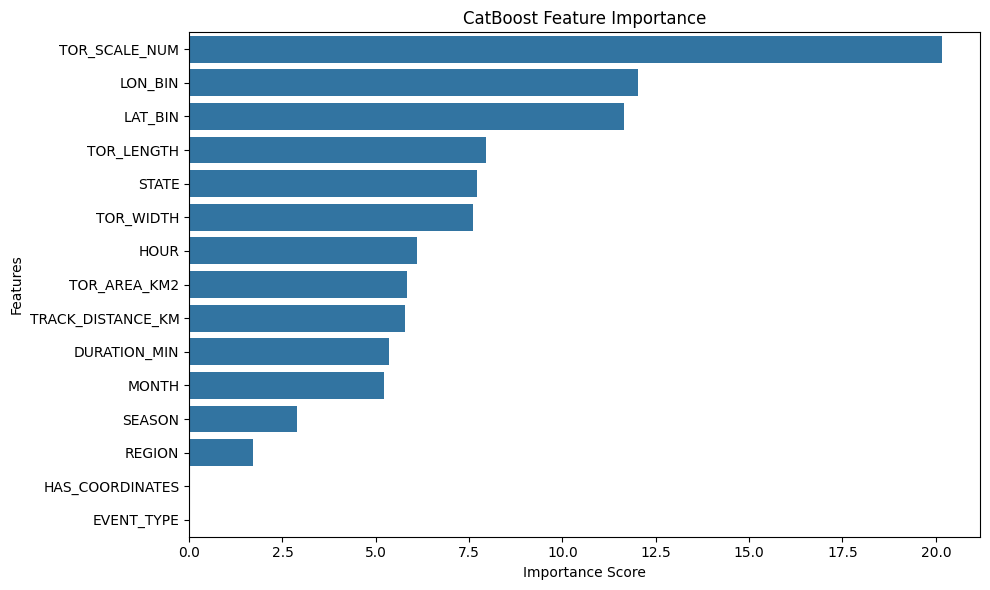

In [8]:
importances = tornado_model.get_feature_importance()
feature_names = tornado_model.feature_names_

# Pack them into a DataFrame for clean sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()